# Predicția categoriei produsului pe baza titlului
**Autor:** Cristiana-Raluca Costache

**Problema:** zilnic intră în magazin mii de produse noi și fiecare trebuie pus în categoria corectă.
Manual durează mult și apar greșeli. Vreau un model care, primind doar **titlul** produsului
(ex. „bosch wap28390gb 8kg 1400 spin”), să sugereze categoria (ex. „Washing Machines”).

**Plan:**
1. Explorarea datelor: ce avem și ce probleme există
2. Curățarea datelor
3. Ingineria caracteristicilor: ce informații „ascunse” are titlul?
4. Compararea mai multor modele și moduri de vectorizare
5. Evaluarea modelului ales (raport pe categorii + matrice de confuzie)
6. Testarea pe titlurile din enunț și concluzii

## 0. Biblioteci

In [1]:
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.svm import LinearSVC

# features.py (din folderul principal) conține funcțiile comune folosite și de scripturi
sys.path.append("..")
from features import LABEL_FIXES, build_model, clean_columns, clean_title, title_stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)

## 1. Explorarea datelor

In [2]:
raw = pd.read_csv("../data/products.csv")
print("Dimensiune:", raw.shape)
raw.head()

Dimensiune: (35311, 8)


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim free smartphone in gold,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked sim free,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


In [3]:
# Numele coloanelor exact cum sunt în fișier (repr arată și spațiile)
print([repr(c) for c in raw.columns])

["'product ID'", "'Product Title'", "'Merchant ID'", "' Category Label'", "'_Product Code'", "'Number_of_Views'", "'Merchant Rating'", "' Listing Date  '"]


**Prima problemă:** numele coloanelor sunt inconsecvente: `' Category Label'` are un spațiu la început,
`'_Product Code'` are underscore, iar `' Listing Date  '` are spații la ambele capete.
Dacă scriu `df["Category Label"]`, primesc eroare. Le standardizez la forma `category_label`, `product_code` etc.

In [4]:
df = clean_columns(raw)
print(df.columns.tolist())
df.info()

['product_id', 'product_title', 'merchant_id', 'category_label', 'product_code', 'number_of_views', 'merchant_rating', 'listing_date']
<class 'pandas.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_id       35311 non-null  int64  
 1   product_title    35139 non-null  str    
 2   merchant_id      35311 non-null  int64  
 3   category_label   35267 non-null  str    
 4   product_code     35216 non-null  str    
 5   number_of_views  35297 non-null  float64
 6   merchant_rating  35141 non-null  float64
 7   listing_date     35252 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.2 MB


In [5]:
# Valori lipsă
missing = df.isna().sum()
pd.DataFrame({"lipsă": missing, "%": (missing / len(df) * 100).round(2)})

,lipsă,%
product_id,0,0.00
product_title,172,0.49
merchant_id,0,0.00
category_label,44,0.12
product_code,95,0.27
number_of_views,14,0.04
merchant_rating,170,0.48
listing_date,59,0.17


In [6]:
# Ce categorii există?
df["category_label"].value_counts(dropna=False)

category_label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
NaN                   44
Name: count, dtype: int64

**Ce observ:**
- Lipsesc **172 de titluri** și **44 de categorii**. Fără ele un rând nu ne ajută la antrenare.
- Există **10 categorii reale**, dar unele apar scrise greșit: `fridge` (123), `CPU` (84), `Mobile Phone` (55).
  Nu le șterg: sunt produse bune, doar cu eticheta scrisă diferit. Le corectez.
- Categoriile nu sunt perfect echilibrate (Fridge Freezers ~5.500, Freezers ~2.200), dar diferența nu e extremă.

In [7]:
# Titlurile: sunt duplicate? au litere mari?
print("Titluri duplicate:", df["product_title"].duplicated().sum())
print("Titluri cu litere mari:", df["product_title"].dropna().str.contains("[A-Z]").sum())
df[df["product_title"].duplicated(keep=False)].sort_values("product_title").head(6)

Titluri duplicate: 4450
Titluri cu litere mari: 0


,product_id,product_title,merchant_id,category_label,product_code,number_of_views,merchant_rating,listing_date
20540,30754,10 kg washing machine with add wash,347,Washing Machines,FO-6789-SN,301.0,3.6,7/20/2024
20676,30898,10 kg washing machine with add wash,347,Washing Machines,GV-5074-SD,2064.0,2.5,2/1/2022
18258,28321,10 place slimline dishwasher 5 progs class a white,123,Dishwashers,AL-9497-ID,2161.0,4.1,2/1/2023
17772,27750,10 place slimline dishwasher 5 progs class a white,123,Dishwashers,ZI-9353-WX,488.0,2.1,10/5/2023
6282,12313,109.22 cm 43 1920 x 1080 lcd smart tv dvb t2/c/s2 2 x hdmi,18,TVs,GO-0561-AY,193.0,4.0,4/17/2024
6438,12475,109.22 cm 43 1920 x 1080 lcd smart tv dvb t2/c/s2 2 x hdmi,18,TVs,SO-0118-GE,2262.0,1.5,3/22/2023


- **~4.450 de titluri se repetă**: același produs e vândut de mai mulți comercianți. Dacă nu le elimin,
  același titlu poate ajunge și în train și în test, iar modelul ar părea mai bun decât e (data leakage).
- **Toate titlurile sunt deja scrise cu litere mici**, așa că ideea din enunț cu „cuvinte scrise cu majuscule (USB, LED)”
  nu se aplică pe aceste date. Am renunțat la ea (primul meu „mini-fail” 🙂).

### Coloanele numerice ajută la ghicirea categoriei?

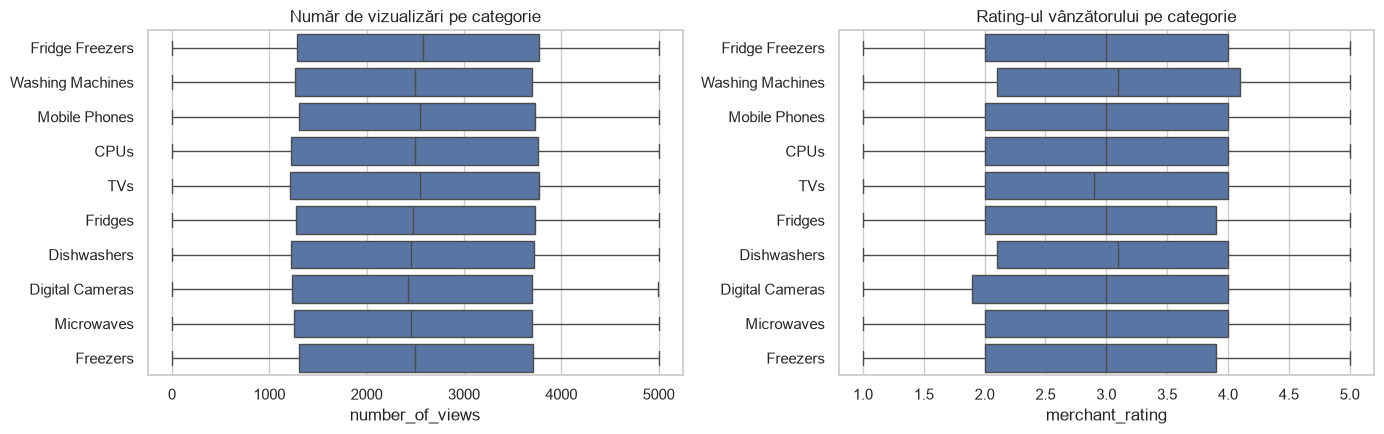

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
order = df["category_label"].value_counts().index[:10]
sns.boxplot(data=df[df["category_label"].isin(order)], y="category_label", x="number_of_views", order=order, ax=axes[0])
axes[0].set_title("Număr de vizualizări pe categorie"); axes[0].set_ylabel("")
sns.boxplot(data=df[df["category_label"].isin(order)], y="category_label", x="merchant_rating", order=order, ax=axes[1])
axes[1].set_title("Rating-ul vânzătorului pe categorie"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

**Concluzie:** vizualizările și rating-ul vânzătorului au **aceeași distribuție în toate categoriile**
(medii de ~2.500 de vizualizări și rating ~3,0 peste tot). Nu spun nimic despre ce fel de produs este.
În plus, la un produs **nou** nu am avea încă vizualizări. Nu le folosesc în model.
`product_code` și `merchant_id` sunt coduri interne fără legătură cu tipul produsului, iar `listing_date` nu are nici ea legătură.
**Toată informația utilă este în titlu.**

## 2. Curățarea datelor
Pași (aceeași logică există și în `features.py`, funcția `load_and_clean`, folosită de `train_model.py`):
1. elimin rândurile fără titlu sau fără categorie;
2. corectez categoriile scrise greșit;
3. normalizez titlurile (litere mici, un singur spațiu între cuvinte);
4. elimin titlurile duplicate.

In [9]:
before = len(df)
df = df.dropna(subset=["product_title", "category_label"])
print("După eliminarea valorilor lipsă:", len(df))

print("Corecturi de etichete:", LABEL_FIXES)
df["category_label"] = df["category_label"].str.strip().replace(LABEL_FIXES)

df["product_title"] = df["product_title"].map(clean_title)
df = df[df["product_title"] != ""]

# Există titluri identice cu categorii diferite? (ar fi etichete contradictorii)
conflicts = df.groupby("product_title")["category_label"].nunique()
print("Titluri cu categorii contradictorii:", (conflicts > 1).sum())

df = df.drop_duplicates(subset="product_title").reset_index(drop=True)
print(f"Rânduri: {before} → {len(df)} după curățare")
df["category_label"].value_counts()

După eliminarea valorilor lipsă: 35096
Corecturi de etichete: {'fridge': 'Fridges', 'CPU': 'CPUs', 'Mobile Phone': 'Mobile Phones'}
Titluri cu categorii contradictorii: 2
Rânduri: 35311 → 30824 după curățare


category_label
Fridge Freezers     4809
Mobile Phones       3662
Washing Machines    3403
TVs                 3275
Fridges             3188
CPUs                3043
Dishwashers         3042
Digital Cameras     2405
Microwaves          2094
Freezers            1903
Name: count, dtype: int64

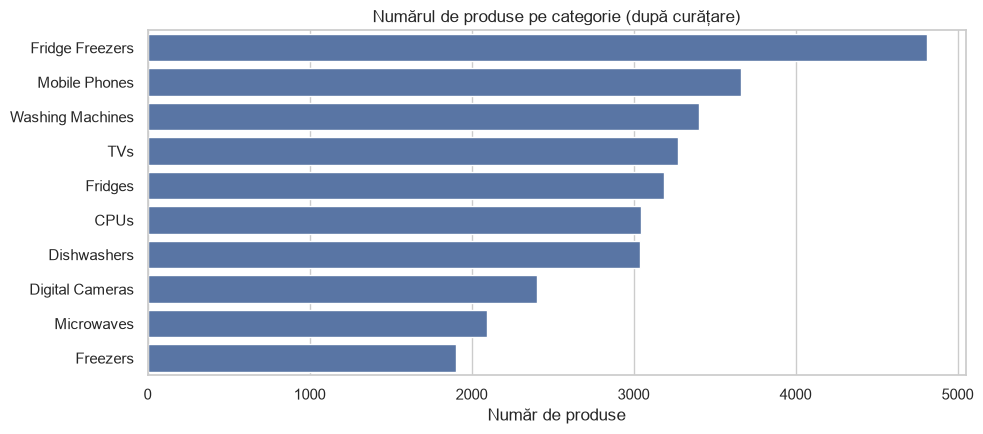

In [10]:
counts = df["category_label"].value_counts()
plt.figure(figsize=(10, 4.5))
sns.barplot(x=counts.values, y=counts.index, color="#4C72B0")
plt.title("Numărul de produse pe categorie (după curățare)")
plt.xlabel("Număr de produse"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 3. Ingineria caracteristicilor
Ce altceva, pe lângă cuvinte, ne poate spune titlul? Am calculat câteva caracteristici simple
(funcția `title_stats` din `features.py`):

| Caracteristică | Ideea din spatele ei |
|---|---|
| `n_words`, `n_chars` | procesoarele au titluri lungi, pline de specificații |
| `n_digits`, `has_number` | telefoanele (GB), camerele (MP) și electrocasnicele (kg, rpm) au multe cifre |
| `longest_word` | codurile de model sunt „cuvinte” lungi (ex. `kgv39vl31g`) |
| `n_special` | `/`, `-`, `+` apar des la telefoane și camere |

In [11]:
stats = title_stats(df["product_title"])
stats["category_label"] = df["category_label"].values
stats.groupby("category_label").mean().round(1)

,n_words,n_chars,n_digits,has_number,longest_word,n_special
category_label,,,,,,
CPUs,12.8,68.6,12.6,1.0,9.4,1.0
Digital Cameras,9.5,49.3,5.8,1.0,7.7,0.5
Dishwashers,6.8,50.2,5.5,1.0,11.1,0.1
Freezers,7.2,48.6,5.3,1.0,10.4,0.1
Fridge Freezers,8.2,55.1,5.6,1.0,10.3,0.2
Fridges,7.5,48.5,5.2,1.0,10.0,0.1
Microwaves,7.6,51.7,5.9,1.0,10.3,0.1
Mobile Phones,8.4,45.6,5.0,0.9,8.0,0.4
TVs,10.1,54.0,9.4,1.0,10.2,0.2


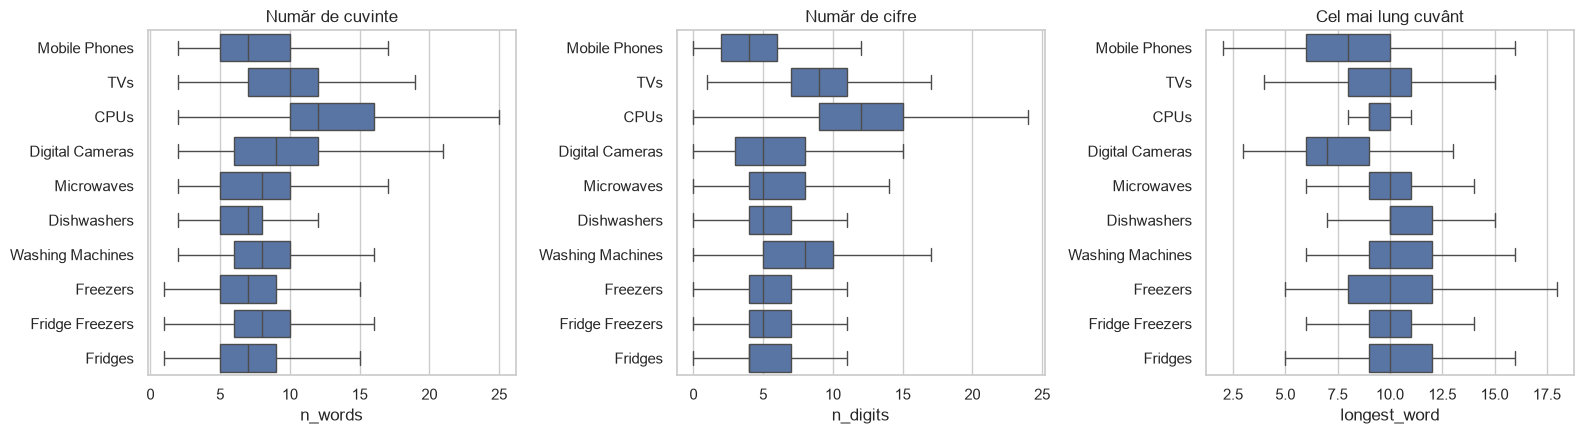

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, title in zip(axes, ["n_words", "n_digits", "longest_word"],
                          ["Număr de cuvinte", "Număr de cifre", "Cel mai lung cuvânt"]):
    sns.boxplot(data=stats, y="category_label", x=col, ax=ax, showfliers=False)
    ax.set_title(title); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Ce observ:**
- **CPUs** ies clar în evidență: ~13 cuvinte pe titlu, față de ~7–8 la electrocasnice.
- **Mobile Phones** și **Digital Cameras** au mai multe caractere speciale și cuvinte mai scurte.
- La **electrocasnice** (frigidere, congelatoare, mașini de spălat) valorile sunt aproape identice.
  Aceste caracteristici nu le pot deosebi. Acolo contează cuvintele și codurile de model.

**O altă idee: bucăți din cuvinte (n-grame de caractere).** Multe titluri conțin doar marca și codul modelului
(ex. `smeg sbs8004po`, `bosch serie 4 kgv39vl31g`). Cuvântul întreg `kgv39vl31g` apare o singură dată,
dar prefixul `kgv` apare la multe combine frigorifice Bosch. Un TF-IDF pe **secvențe de 2–5 caractere**
poate învăța astfel de tipare. Verific ipoteza mai jos.

## 4. Compararea modelelor
Împart datele 80/20 (`stratify` păstrează proporția categoriilor, `random_state=42` face împărțirea reproductibilă).
Compar **3 algoritmi** × **2 moduri de vectorizare**, apoi combinații de caracteristici.

In [13]:
X, y = df["product_title"], df["category_label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 24659 | Test: 6165


In [14]:
vectorizers = {
    "TF-IDF cuvinte (1-2)": lambda: TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True),
    "TF-IDF caractere (2-5)": lambda: TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True),
}
algorithms = {
    "Naive Bayes": lambda: MultinomialNB(alpha=0.1),
    "Logistic Regression": lambda: LogisticRegression(max_iter=2000, C=10),
    "Linear SVC": lambda: LinearSVC(random_state=42),
}

rows = []
for vec_name, make_vec in vectorizers.items():
    for alg_name, make_alg in algorithms.items():
        model = Pipeline([("tfidf", make_vec()), ("clf", make_alg())])
        start = time.time()
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        rows.append({"Vectorizare": vec_name, "Model": alg_name,
                     "Acuratețe": accuracy_score(y_test, pred),
                     "F1 macro": f1_score(y_test, pred, average="macro"),
                     "Timp antrenare (s)": round(time.time() - start, 1)})
        print(f"✔ {vec_name} + {alg_name}")

results = pd.DataFrame(rows).sort_values("F1 macro", ascending=False).reset_index(drop=True)
results.round(4)

✔ TF-IDF cuvinte (1-2) + Naive Bayes
✔ TF-IDF cuvinte (1-2) + Logistic Regression
✔ TF-IDF cuvinte (1-2) + Linear SVC
✔ TF-IDF caractere (2-5) + Naive Bayes
✔ TF-IDF caractere (2-5) + Logistic Regression
✔ TF-IDF caractere (2-5) + Linear SVC


,Vectorizare,Model,Acuratețe,F1 macro,Timp antrenare (s)
0,TF-IDF caractere (2-5),Linear SVC,0.9919,0.9919,2.7
1,TF-IDF caractere (2-5),Logistic Regression,0.9890,0.9891,7.6
2,TF-IDF caractere (2-5),Naive Bayes,0.9813,0.9814,1.9
3,TF-IDF cuvinte (1-2),Naive Bayes,0.9744,0.9749,0.4
4,TF-IDF cuvinte (1-2),Linear SVC,0.9635,0.9645,0.5
5,TF-IDF cuvinte (1-2),Logistic Regression,0.9588,0.9599,5.1


*F1 macro* = media F1 pe toate categoriile, fiecare categorie cântărind la fel. E mai corectă decât acuratețea
când categoriile au mărimi diferite.

**Ce observ:**
- **N-gramele de caractere câștigă la toți algoritmii**: +0,7 puncte procentuale la Naive Bayes și aproape +3 la Linear SVC
  și Logistic Regression. Ipoteza cu codurile de model s-a confirmat.
- **Linear SVC + caractere** este cea mai bună combinație (99,2% acuratețe) și se antrenează în câteva secunde.
  Logistic Regression e aproape la fel de bun, dar de ~4 ori mai lent.
- Surpriză: pe cuvinte întregi, **Naive Bayes** a fost mai bun decât SVC și LR. Pe caractere, ordinea se inversează.

### Combinații de caracteristici (cu Linear SVC)

In [15]:
def char_tfidf():
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True)

def word_tfidf():
    return TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)

def stats_block():
    return Pipeline([("extract", FunctionTransformer(title_stats)), ("scale", MinMaxScaler())])

candidates = {
    "A. caractere": Pipeline([("f", char_tfidf()), ("clf", LinearSVC(random_state=42))]),
    "B. caractere + cuvinte": Pipeline([("f", FeatureUnion([("c", char_tfidf()), ("w", word_tfidf())])),
                                        ("clf", LinearSVC(random_state=42))]),
    "C. caractere + cuvinte + statistici titlu": build_model(),   # modelul din features.py
}

test_titles = pd.DataFrame({
    "titlu": ["iphone 7 32gb gold,4,3,Apple iPhone 7 32GB", "olympus e m10 mark iii geh use silber",
              "kenwood k20mss15 solo", "bosch wap28390gb 8kg 1400 spin", "bosch serie 4 kgv39vl31g", "smeg sbs8004po"],
    "așteptat": ["Mobile Phones", "Digital Cameras", "Microwaves", "Washing Machines", "Fridge Freezers", "Fridge Freezers"],
})

combo_rows = []
for name, model in candidates.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    title_pred = model.predict(test_titles["titlu"].map(clean_title))
    test_titles[name] = title_pred
    combo_rows.append({"Caracteristici": name,
                       "Acuratețe": accuracy_score(y_test, pred),
                       "F1 macro": f1_score(y_test, pred, average="macro"),
                       "Titluri din enunț corecte": f"{(title_pred == test_titles['așteptat']).sum()} / 6"})

pd.DataFrame(combo_rows).round(4)

,Caracteristici,Acuratețe,F1 macro,Titluri din enunț corecte
0,A. caractere,0.9919,0.9919,5 / 6
1,B. caractere + cuvinte,0.9890,0.9890,6 / 6
2,C. caractere + cuvinte + statistici titlu,0.9891,0.9892,6 / 6


In [16]:
# Unde greșesc variantele pe cele 6 titluri din enunț?
test_titles

,titlu,așteptat,A. caractere,B. caractere + cuvinte,C. caractere + cuvinte + statistici titlu
0,"iphone 7 32gb gold,4,3,Apple iPhone 7 32GB",Mobile Phones,Mobile Phones,Mobile Phones,Mobile Phones
1,olympus e m10 mark iii geh use silber,Digital Cameras,Digital Cameras,Digital Cameras,Digital Cameras
2,kenwood k20mss15 solo,Microwaves,Fridges,Microwaves,Microwaves
3,bosch wap28390gb 8kg 1400 spin,Washing Machines,Washing Machines,Washing Machines,Washing Machines
4,bosch serie 4 kgv39vl31g,Fridge Freezers,Fridge Freezers,Fridge Freezers,Fridge Freezers
5,smeg sbs8004po,Fridge Freezers,Fridge Freezers,Fridge Freezers,Fridge Freezers


**Dilema mea:** varianta **A (doar caractere)** are cea mai mare acuratețe pe setul de test, dar clasifică
`kenwood k20mss15 solo` ca **Fridges** în loc de Microwaves. Variantele **B** și **C** au o acuratețe
cu ~0,3 puncte mai mică, dar recunosc **corect toate cele 6 titluri**.

Motivul, cred: în titlurile scurte, formate aproape numai din cod, n-gramele de caractere „se încurcă”.
Cuvântul întreg **solo** („microunde solo”, fără grill) este un indiciu clar, iar abia TF-IDF-ul pe cuvinte îl folosește.

**Statisticile titlului** (varianta C față de B) schimbă rezultatul cu doar ~0,01 puncte procentuale, practic nimic.
Le păstrez în model pentru că nu strică, dar notez sincer că **nu ele fac diferența**. Informația lor
(lungime, cifre) este deja „văzută” indirect de TF-IDF.

Ca să nu decid pe baza unei singure împărțiri a datelor, verific A și C cu **validare încrucișată pe 5 fold-uri**.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name in ["A. caractere", "C. caractere + cuvinte + statistici titlu"]:
    model = candidates[name]
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    print(f"{name:45s} F1 macro = {scores.mean():.4f} ± {scores.std():.4f}")

A. caractere                                  F1 macro = 0.9915 ± 0.0008
C. caractere + cuvinte + statistici titlu     F1 macro = 0.9893 ± 0.0006


**Rezultatul validării încrucișate:** varianta A este **constant puțin mai bună**, cu ~0,2 puncte procentuale
(99,15% față de 98,93%), iar variația între fold-uri e foarte mică. Deci diferența este reală, nu noroc.
Înseamnă aproximativ 13–14 greșeli în plus la 6.000 de produse pentru varianta C.

**Decizia mea este un compromis conștient: ➡ aleg varianta C** (caractere + cuvinte + statistici titlu, cu Linear SVC),
adică funcția `build_model()` din `features.py`.
- În practică, colegii vor introduce des **titluri scurte, doar marcă + cod** (ca în exemplele din enunț). Acolo varianta A
  a greșit un caz evident (`kenwood k20mss15 solo`), în timp ce C le-a nimerit pe toate.
- Pierderea de 0,2 pp pe setul de test este mică, iar C folosește și cuvintele întregi, deci e mai ușor de „explicat”.
- Notez sincer: am luat decizia pe baza a doar 6 exemple manuale. Într-o versiune următoare aș construi un set de test
  separat cu titluri scurte, ca să verific decizia pe mai multe cazuri.

## 5. Evaluarea modelului final

In [18]:
final = candidates["C. caractere + cuvinte + statistici titlu"]
y_pred = final.predict(X_test)
print(f"Acuratețe: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, digits=3))

Acuratețe: 0.9891

                  precision    recall  f1-score   support

            CPUs      0.998     0.995     0.997       609
 Digital Cameras      1.000     1.000     1.000       481
     Dishwashers      0.993     0.997     0.995       608
        Freezers      0.981     0.971     0.976       380
 Fridge Freezers      0.975     0.991     0.983       962
         Fridges      0.974     0.958     0.966       638
      Microwaves      0.998     0.986     0.992       419
   Mobile Phones      0.996     0.995     0.995       732
             TVs      0.995     0.998     0.997       655
Washing Machines      0.988     0.994     0.991       681

        accuracy                          0.989      6165
       macro avg      0.990     0.988     0.989      6165
    weighted avg      0.989     0.989     0.989      6165



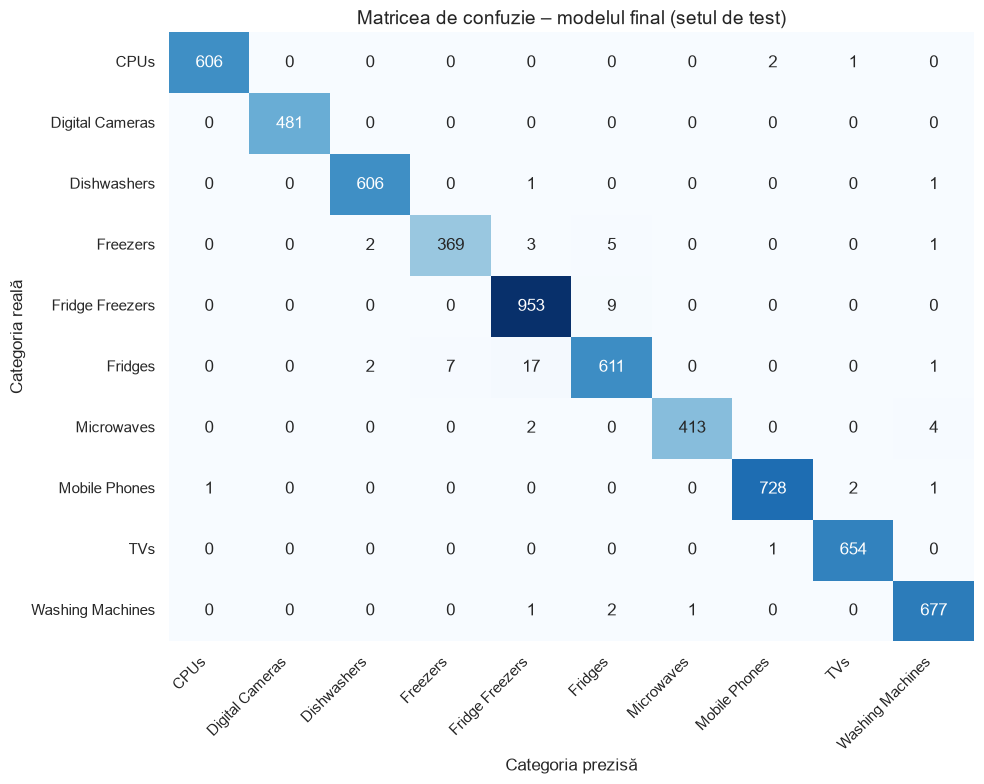

In [19]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False)
plt.title("Matricea de confuzie – modelul final (setul de test)", fontsize=14)
plt.xlabel("Categoria prezisă"); plt.ylabel("Categoria reală")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

In [20]:
# Cele mai frecvente confuzii (în afara diagonalei)
pairs = [(labels[i], labels[j], cm[i, j]) for i in range(len(labels)) for j in range(len(labels)) if i != j and cm[i, j] > 0]
pd.DataFrame(pairs, columns=["real", "prezis", "număr"]).sort_values("număr", ascending=False).head(8)

,real,prezis,număr
11,Fridges,Fridge Freezers,17
8,Fridge Freezers,Fridges,9
10,Fridges,Freezers,7
6,Freezers,Fridges,5
14,Microwaves,Washing Machines,4
5,Freezers,Fridge Freezers,3
20,Washing Machines,Fridges,2
13,Microwaves,Fridge Freezers,2


In [21]:
# Exemple de greșeli
errors = pd.DataFrame({"titlu": X_test, "real": y_test, "prezis": y_pred})
errors[errors["real"] != errors["prezis"]].head(12)

,titlu,real,prezis
26835,neff k hlger t kgf 735 a2,Fridge Freezers,Fridges
30306,gorenje k hlger t rb 4061 aw,Fridges,Freezers
5273,silicon power computer communications inc silicon power s55 120 gb 2.5inch internal so...,TVs,Mobile Phones
22632,gorenje f4152cw,Freezers,Fridges
30656,smeg fab28rrv1 fridge freezer,Fridges,Fridge Freezers
15943,amica ziv635,Dishwashers,Fridge Freezers
3209,samsung e1200,Mobile Phones,Washing Machines
26232,zanussi zrb 36104 xa eek a skala a bis d 925053505,Fridge Freezers,Fridges
22280,hotpoint huz12221,Freezers,Washing Machines
27480,2. wahl aeg santo scs51800s1 178cm 2667495 eek a skala a bis d santo scs51800s1,Fridge Freezers,Fridges


**Unde greșește modelul?** Din ~67 de greșeli pe setul de test, **peste jumătate (~41)** sunt între **Fridges, Freezers și Fridge Freezers**.
E de înțeles: sunt produse foarte asemănătoare, de la aceiași producători, cu coduri de model apropiate,
iar uneori titlul nu conține deloc cuvântul „fridge” sau „freezer”. La restul categoriilor (TVs, CPUs, camere, telefoane)
modelul este aproape perfect. Câteva confuzii Microwaves → Washing Machines apar la titluri formate aproape numai din cod.

## 6. Concluzii

| | |
|---|---|
| **Model ales** | Linear SVC pe TF-IDF de caractere (2–5) + TF-IDF de cuvinte (1–2) + statistici ale titlului |
| **Date** | 35.311 rânduri → 30.824 după curățare, 10 categorii |
| **Acuratețe pe test** | ~98,9% (F1 macro ~0,99) |
| **Titluri din enunț** | 6 din 6 corecte |
| **Puncte slabe** | confuzii între Fridges / Freezers / Fridge Freezers |

**Ce am învățat:**
1. **Curățarea contează:** nume de coloane cu spații, etichete scrise diferit și ~4.400 de titluri duplicate.
   Fără curățare, rezultatele ar fi fost umflate artificial.
2. **Cea mai valoroasă „caracteristică” au fost n-gramele de caractere**, pentru că prind codurile de model.
   Statisticile simple ale titlului au adus foarte puțin.
3. **Acuratețea maximă nu înseamnă automat cel mai bun model:** varianta cu scorul cel mai mare (doar caractere, 99,2%)
   greșea un exemplu real, simplu. Am ales conștient un model cu 0,2 pp mai puțin, dar mai robust pe titluri scurte.
4. Metadatele (vizualizări, rating, dată) nu au nicio legătură cu categoria.

**Idei pentru versiunea următoare:**
- să arătăm utilizatorului și **top 3 categorii** (cu scor), ca să aleagă rapid când modelul nu e sigur;
- un dicționar de **prefixe de coduri pe producător** (ex. Bosch `kgv` = combină frigorifică), pentru cele 3 categorii de frig;
- reantrenare periodică pe produsele noi, corectate de colegi.

Modelul final se antrenează și se salvează cu `python train_model.py`, iar testarea se face cu `python predict_category.py`.